In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('D:/4651050029-PhamBinhChuong/SoLieuCPDieuTri2016.xlsx')
print(df.shape)
df.head()

(68762, 15)


,ID,NAMSINH,Unnamed: 2,DANTOC,TENPXA,TENQUANHUYEN,TENTINHTHANH,MAICD,CHANDOAN,NGAYVAO,NGAYRA,TONGCP,BHYT_TT,Unnamed: 13,Unnamed: 14
0,160101000007636000,1988,NaN,Kinh,Phường Nhơn Bình,Thành phố Qui Nhơn,Bình Định,S01.1;,Vết thương hở của mi mắt và vùng quanh mắt;,2016-01-01 00:55:00,2016-01-01 01:04:00,15000.00000,0.0000,NaN,0.0
1,160101000007640000,1998,NaN,Kinh,Phường Nhơn Phú,Thành phố Qui Nhơn,Bình Định,I20;,Cơn đau thắt ngực;,2016-01-01 01:37:00,2016-01-01 03:23:00,83346.50000,83346.5000,NaN,NaN
2,160101000007640992,1980,NaN,Kinh,Xã Nhơn Lộc,Thị xã An Nhơn,Bình Định,J68.2;P71.0;,Viêm hô hấp trên;Hạ calci máu;,2016-01-01 03:31:00,2016-01-01 05:00:00,159.99900,0.0000,NaN,NaN
3,160104000001348000,2010,NaN,Kinh,Phường Trần Quang Diệu,Thành phố Qui Nhơn,Bình Định,A91.A;,Sốt xuất huyết Dengue;,2015-12-29 20:25:00,2016-01-01 07:00:00,112938.00000,112938.0000,NaN,NaN
4,160105000001870016,2010,NaN,Kinh,Phường Nhơn Phú,Thành phố Qui Nhơn,Bình Định,A91;J00;,Sốt xuất huyết Dengue;Viêm Họng Cấp;,2015-12-25 08:44:00,2016-01-01 07:00:00,262395.00025,262395.0003,NaN,NaN


In [16]:
#  1. Hiểu dữ liệu
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68762 entries, 0 to 68761
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ID            68762 non-null  int64         
 1   NAMSINH       68762 non-null  int64         
 2   Unnamed: 2    0 non-null      float64       
 3   DANTOC        68762 non-null  object        
 4   TENPXA        68762 non-null  object        
 5   TENQUANHUYEN  68762 non-null  object        
 6   TENTINHTHANH  68762 non-null  object        
 7   MAICD         68762 non-null  object        
 8   CHANDOAN      68762 non-null  object        
 9   NGAYVAO       68762 non-null  datetime64[ns]
 10  NGAYRA        68762 non-null  datetime64[ns]
 11  TONGCP        68762 non-null  float64       
 12  BHYT_TT       68762 non-null  float64       
 13  Unnamed: 13   0 non-null      float64       
 14  Unnamed: 14   1 non-null      float64       
dtypes: datetime64[ns](2), float64(5), in

In [19]:
print(f'Tổng số hồ sơ: {len(df)}')
print(f'Số bệnh nhân duy nhất: {df["ID"].nunique()}')
print(f'Thời gian: {df["NGAYVAO"].min().date()} đến {df["NGAYVAO"].max().date()}')

Tổng số hồ sơ: 68762
Số bệnh nhân duy nhất: 67796
Thời gian: 2010-04-09 đến 2016-12-31


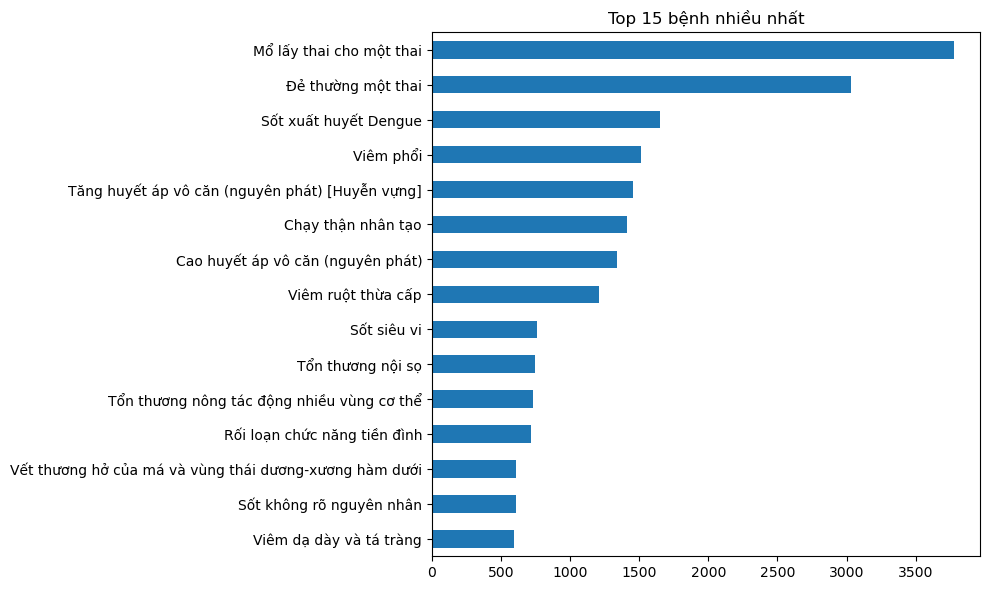

In [21]:
#Bệnh nào nhiều nhất
diseases = []
for d in df['CHANDOAN']:
    for p in str(d).split(';'):
        p = p.strip()
        if p:
            diseases.append(p)

top15 = pd.Series(Counter(diseases)).sort_values(ascending=False).head(15)
top15.plot(kind='barh', figsize=(10, 6), title='Top 15 bệnh nhiều nhất')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

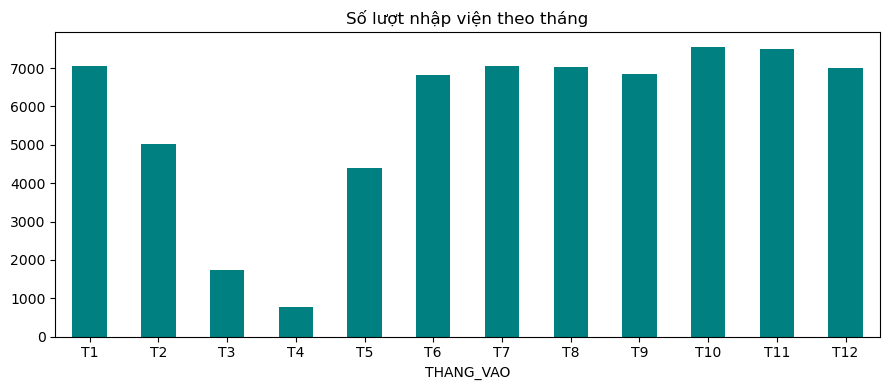

In [22]:
# Thời gian nào nhiều (theo tháng)
df['THANG_VAO'] = pd.to_datetime(df['NGAYVAO']).dt.month
df['THANG_VAO'].value_counts().sort_index().plot(
    kind='bar', figsize=(9, 4), title='Số lượt nhập viện theo tháng', color='teal')
plt.xticks(range(12), [f'T{i+1}' for i in range(12)], rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# 2a. Chuyển đổi thành mùa
df['TGDT_NGAY'] = (pd.to_datetime(df['NGAYRA']) - pd.to_datetime(df['NGAYVAO'])).dt.days

# Hàm chuyển tháng → mùa
def thang_to_mua(thang):
    if 1 <= thang <= 3:
        return 'Xuân'
    elif 4 <= thang <= 6:
        return 'Hè'
    elif 7 <= thang <= 9:
        return 'Thu'
    else:
        return 'Đông'

df['THANG_VAO'] = pd.to_datetime(df['NGAYVAO']).dt.month
df['MUA_VAO']   = df['THANG_VAO'].apply(thang_to_mua)

df['THANG_RA']  = pd.to_datetime(df['NGAYRA']).dt.month
df['MUA_RA']    = df['THANG_RA'].apply(thang_to_mua)

print(df[['NGAYVAO','NGAYRA','TGDT_NGAY','MUA_VAO','MUA_RA']].head())
print('\nPhân bố mùa vào viện:')
print(df['MUA_VAO'].value_counts())

              NGAYVAO              NGAYRA  TGDT_NGAY MUA_VAO MUA_RA
0 2016-01-01 00:55:00 2016-01-01 01:04:00          0    Xuân   Xuân
1 2016-01-01 01:37:00 2016-01-01 03:23:00          0    Xuân   Xuân
2 2016-01-01 03:31:00 2016-01-01 05:00:00          0    Xuân   Xuân
3 2015-12-29 20:25:00 2016-01-01 07:00:00          2    Đông   Xuân
4 2015-12-25 08:44:00 2016-01-01 07:00:00          6    Đông   Xuân

Phân bố mùa vào viện:
MUA_VAO
Đông    22061
Thu     20914
Xuân    13796
Hè      11991
Name: count, dtype: int64


In [25]:
# 2b. Xử lý dữ liệu thiếu
print('Giá trị thiếu:')
print(df.isnull().sum())

# Xóa cột hoàn toàn trống
df.drop(columns=['Unnamed: 2', 'Unnamed: 13', 'Unnamed: 14'], inplace=True)

# Điền BHYT_TT thiếu = 0
df['BHYT_TT'] = df['BHYT_TT'].fillna(0)

print('\nSau xử lý:')
print(df.isnull().sum())

Giá trị thiếu:
ID                  0
NAMSINH             0
Unnamed: 2      68762
DANTOC              0
TENPXA              0
TENQUANHUYEN        0
TENTINHTHANH        0
MAICD               0
CHANDOAN            0
NGAYVAO             0
NGAYRA              0
TONGCP              0
BHYT_TT             0
Unnamed: 13     68762
Unnamed: 14     68761
THANG_VAO           0
TGDT_NGAY           0
MUA_VAO             0
THANG_RA            0
MUA_RA              0
dtype: int64

Sau xử lý:
ID              0
NAMSINH         0
DANTOC          0
TENPXA          0
TENQUANHUYEN    0
TENTINHTHANH    0
MAICD           0
CHANDOAN        0
NGAYVAO         0
NGAYRA          0
TONGCP          0
BHYT_TT         0
THANG_VAO       0
TGDT_NGAY       0
MUA_VAO         0
THANG_RA        0
MUA_RA          0
dtype: int64


Trước xử lý:
count    68762.000000
mean         7.070693
std         17.476999
min         -6.000000
25%          2.000000
50%          4.000000
75%          8.000000
max       2142.000000
Name: TGDT_NGAY, dtype: float64
Ngưỡng: [-7.0, 17.0] ngày
Số outlier: 4777


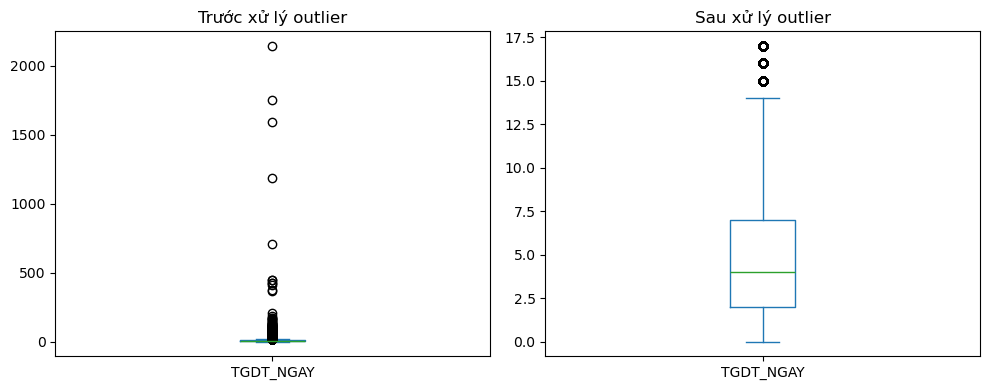

Số hồ sơ còn lại: 63964


In [26]:
# 2c. Outlier cột thời gian điều trị
print('Trước xử lý:')
print(df['TGDT_NGAY'].describe())

# Loại dòng có thời gian âm (lỗi nhập liệu)
df = df[df['TGDT_NGAY'] >= 0].copy()

# Phát hiện outlier bằng IQR
Q1  = df['TGDT_NGAY'].quantile(0.25)
Q3  = df['TGDT_NGAY'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Ngưỡng: [{lower:.1f}, {upper:.1f}] ngày')
print(f'Số outlier: {((df["TGDT_NGAY"] < lower) | (df["TGDT_NGAY"] > upper)).sum()}')

# Boxplot trước/sau
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['TGDT_NGAY'].plot(kind='box', ax=axes[0], title='Trước xử lý outlier')
df_clean = df[(df['TGDT_NGAY'] >= lower) & (df['TGDT_NGAY'] <= upper)].copy()
df_clean['TGDT_NGAY'].plot(kind='box', ax=axes[1], title='Sau xử lý outlier')
plt.tight_layout()
plt.show()

df = df_clean.copy()
print(f'Số hồ sơ còn lại: {len(df)}')

In [27]:
#  2d. Chuyển đổi sang số, phân khoảng
from sklearn.preprocessing import LabelEncoder

# Tính tuổi
df['TUOI'] = 2016 - df['NAMSINH']

# Phân khoảng tuổi
bins   = [0, 5, 15, 30, 45, 60, 200]
labels = ['<5', '5-14', '15-29', '30-44', '45-59', '60+']
df['NHOM_TUOI'] = pd.cut(df['TUOI'], bins=bins, labels=labels, right=False)
print(df['NHOM_TUOI'].value_counts().sort_index())

# Mã hóa các cột chữ sang số
le = LabelEncoder()
df['DANTOC_MA']   = le.fit_transform(df['DANTOC'])
df['MUA_VAO_MA']  = le.fit_transform(df['MUA_VAO'])
df['NHOM_TUOI_MA']= le.fit_transform(df['NHOM_TUOI'].astype(str))

print(df[['DANTOC','DANTOC_MA','MUA_VAO','MUA_VAO_MA','NHOM_TUOI','NHOM_TUOI_MA']].head())

NHOM_TUOI
<5        8966
5-14      4262
15-29    13790
30-44    10736
45-59     9848
60+      16362
Name: count, dtype: int64
  DANTOC  DANTOC_MA MUA_VAO  MUA_VAO_MA NHOM_TUOI  NHOM_TUOI_MA
0   Kinh         10    Xuân           2     15-29             0
1   Kinh         10    Xuân           2     15-29             0
2   Kinh         10    Xuân           2     30-44             1
3   Kinh         10    Đông           3      5-14             3
4   Kinh         10    Đông           3      5-14             3


In [28]:
# 2e. Chọn thuộc tính
# Thuộc tính đầu vào: tuổi, dân tộc (mã số), chi phí, thời gian điều trị, có BHYT
# Nhãn lớp: MUA_VAO

df['CO_BHYT'] = (df['BHYT_TT'] > 0).astype(int)

feature_cols = ['TUOI', 'DANTOC_MA', 'TONGCP', 'TGDT_NGAY', 'CO_BHYT', 'NHOM_TUOI_MA']
label_col    = 'MUA_VAO_MA'

df_model = df[feature_cols + [label_col]].dropna()
X = df_model[feature_cols].values
y = df_model[label_col].values

print('Thuộc tính:', feature_cols)
print('Nhãn lớp: MUA_VAO_MA (0=Đông, 1=Hè, 2=Thu, 3=Xuân)')
print(f'Số mẫu: {len(df_model)}')

Thuộc tính: ['TUOI', 'DANTOC_MA', 'TONGCP', 'TGDT_NGAY', 'CO_BHYT', 'NHOM_TUOI_MA']
Nhãn lớp: MUA_VAO_MA (0=Đông, 1=Hè, 2=Thu, 3=Xuân)
Số mẫu: 63964
